In [1]:
import os

# Fix: must set protobuf runtime env vars before any TF/Keras/protobuf-related import.
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION_VERSION"] = "2"
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION_DISABLE_CEXT"] = "1"

import sys
import random
import numpy as np
import pandas as pd

from glob import glob
from skimage.io import imread
import gc

from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Listing ../input:", os.listdir("../input")[:10])



Listing ../input: ['description.md', 'test', 'train', 'histopathologic-cancer-detection', 'test.zip', 'train.zip', 'train_labels.csv', 'sample_submission.csv.zip', 'train_labels.csv.zip', 'sample_submission.csv']


In [2]:
DATA_ROOT = "../input/histopathologic-cancer-detection"
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
TEST_DIR = os.path.join(DATA_ROOT, "test")
LABELS_CSV = os.path.join(DATA_ROOT, "train_labels.csv")
SAMPLE_SUB_CSV = os.path.join(DATA_ROOT, "sample_submission.csv")

if not os.path.exists(TRAIN_DIR):
    TRAIN_DIR = "../input/train"
if not os.path.exists(TEST_DIR):
    TEST_DIR = "../input/test"
if not os.path.exists(LABELS_CSV):
    LABELS_CSV = "../input/train_labels.csv"
if not os.path.exists(SAMPLE_SUB_CSV):
    SAMPLE_SUB_CSV = "../input/sample_submission.csv"

print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR :", TEST_DIR)
print("LABELS   :", LABELS_CSV)
print("SAMPLE   :", SAMPLE_SUB_CSV)

base_tile_dir = TRAIN_DIR
df = pd.DataFrame({"path": glob(os.path.join(base_tile_dir, "*.tif"))})
df["id"] = df["path"].map(lambda x: os.path.splitext(os.path.basename(x))[0])

labels = pd.read_csv(LABELS_CSV)
df = df.merge(labels, on="id")
df.head(3)



TRAIN_DIR: ../input/histopathologic-cancer-detection/train
TEST_DIR : ../input/histopathologic-cancer-detection/test
LABELS   : ../input/histopathologic-cancer-detection/train_labels.csv
SAMPLE   : ../input/histopathologic-cancer-detection/sample_submission.csv


,path,id,label
0,../input/histopathologic-cancer-detection/trai...,bc9b47c5fd125f59519a4f719bf459f919164104,0
1,../input/histopathologic-cancer-detection/trai...,0874a429121cea137156954353d1b287022a6f65,0
2,../input/histopathologic-cancer-detection/trai...,0ca7627eaf902b8f6e4bb5d171a2dd485abd0d88,0


In [3]:
import importlib


def _purge_protobuf_related_modules():
    # Fix: remove any already-imported protobuf C-extension bindings so TF can't latch onto them.
    for m in list(sys.modules.keys()):
        if (
            m == "google.protobuf"
            or m.startswith("google.protobuf.")
            or m.startswith("google._upb")
            or m.startswith("google.protobuf.pyext")
            or m.startswith("google.protobuf.internal._")
        ):
            del sys.modules[m]


def _enforce_pure_python_protobuf_runtime():
    os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"
    os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION_VERSION"] = "2"
    os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION_DISABLE_CEXT"] = "1"
    _purge_protobuf_related_modules()
    importlib.invalidate_caches()


def _import_tf_and_keras_safely():
    """
    Fix: The crash `AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'`
    happens during TensorFlow import when protobuf runtime bindings are incompatible.
    Enforce pure-python protobuf + purge protobuf modules, then import TensorFlow once.
    """
    _enforce_pure_python_protobuf_runtime()
    last_err = None

    for attempt in range(3):
        try:
            import tensorflow as tf

            # Determinism/stability: doesn't change core logic, but reduces run-to-run drift.
            try:
                tf.random.set_seed(SEED)
            except Exception:
                pass

            from tensorflow.keras.utils import to_categorical

            return tf, to_categorical, "tf.keras (tensorflow)"
        except Exception as e_tf:
            last_err = e_tf
            _enforce_pure_python_protobuf_runtime()

    raise RuntimeError(
        "Failed to import TensorFlow/Keras due to protobuf incompatibility.\n"
        f"Last TensorFlow import error: {repr(last_err)}"
    )


tf, to_categorical, KERAS_BACKEND = _import_tf_and_keras_safely()
print("Using Keras backend:", KERAS_BACKEND)
print("TensorFlow version:", getattr(tf, "__version__", "unknown"))

SAMPLES_N = 10000
SAMPLES_P = 10000

n0 = min(SAMPLES_N, int((df.label == 0).sum()))
n1 = min(SAMPLES_P, int((df.label == 1).sum()))

df0 = df[df.label == 0].sample(n0, random_state=SEED)
df1 = df[df.label == 1].sample(n1, random_state=SEED)
df = pd.concat([df0, df1], ignore_index=True).reset_index(drop=True)

df = df[["path", "id", "label"]]
df["image"] = df["path"].map(imread)

y = df["label"].values
X = np.stack(df["image"].values)

y = to_categorical(y, num_classes=2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=SEED, stratify=y.argmax(axis=1)
)

X_train = X_train.astype("float32")
X_test = X_test.astype("float32")
train_mean = X_train.mean()
train_std = X_train.std() + 1e-7
X_train = (X_train - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

gc.collect()



2026-01-16 03:48:39.831812: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768535319.843283      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768535319.847530      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-16 03:48:39.866797: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Using Keras backend: tf.keras (tensorflow)
TensorFlow version: 2.18.0


3706

In [4]:
# Fix: Use the already-imported TensorFlow backend consistently to avoid mixed-import protobuf issues.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPool2D
from tensorflow.keras.optimizers import Adam

kernel_size = (3, 3)
pool_size = (2, 2)
first_filters = 32
second_filters = 64
third_filters = 128

dropout_conv = 0.3
dropout_dense = 0.3

model = Sequential()
model.add(
    Conv2D(first_filters, kernel_size, activation="relu", input_shape=(96, 96, 3))
)
model.add(Conv2D(first_filters, kernel_size, activation="relu"))
model.add(Conv2D(first_filters, kernel_size, activation="relu"))
model.add(MaxPool2D(pool_size=pool_size))
model.add(Dropout(dropout_conv))

model.add(Conv2D(second_filters, kernel_size, activation="relu"))
model.add(Conv2D(second_filters, kernel_size, activation="relu"))
model.add(Conv2D(second_filters, kernel_size, activation="relu"))
model.add(MaxPool2D(pool_size=pool_size))
model.add(Dropout(dropout_conv))

model.add(Conv2D(third_filters, kernel_size, activation="relu"))
model.add(Conv2D(third_filters, kernel_size, activation="relu"))
model.add(Conv2D(third_filters, kernel_size, activation="relu"))
model.add(MaxPool2D(pool_size=pool_size))
model.add(Dropout(dropout_conv))

model.add(Flatten())
model.add(Dense(256, activation="relu"))
model.add(Dropout(dropout_dense))
model.add(Dense(2, activation="softmax"))

optimizer = Adam(
    learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-7, amsgrad=False
)

model.compile(
    optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"]
)
model.summary()



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-16 03:49:04.616661: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1768535344.617146      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 40005 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:46:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 92, 92, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 90, 90, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 43, 43, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 41, 41, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 39, 39, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 19, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 19, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 17, 17, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 13, 13, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,661,186 (6.34 MB)

 Trainable params: 1,661,186 (6.34 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
from tensorflow.keras.callbacks import EarlyStopping

earlystopper = EarlyStopping(
    monitor="val_loss", patience=2, verbose=1, restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=64,
    callbacks=[earlystopper],
    verbose=2,
)



Epoch 1/5


I0000 00:00:1768535350.155865      66 service.cc:148] XLA service 0x7f2a18015860 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768535350.155905      66 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-01-16 03:49:10.198241: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1768535350.441985      66 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1768535355.541982      66 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


210/210 - 19s - 90ms/step - accuracy: 0.7172 - loss: 0.5548 - val_accuracy: 0.7861 - val_loss: 0.4986
Epoch 2/5
210/210 - 4s - 17ms/step - accuracy: 0.7896 - loss: 0.4652 - val_accuracy: 0.7985 - val_loss: 0.4463
Epoch 3/5
210/210 - 3s - 17ms/step - accuracy: 0.8089 - loss: 0.4328 - val_accuracy: 0.8314 - val_loss: 0.3894
Epoch 4/5
210/210 - 4s - 17ms/step - accuracy: 0.8209 - loss: 0.4128 - val_accuracy: 0.8467 - val_loss: 0.3615
Epoch 5/5
210/210 - 4s - 17ms/step - accuracy: 0.8271 - loss: 0.3973 - val_accuracy: 0.8405 - val_loss: 0.3643
Restoring model weights from the end of the best epoch: 4.


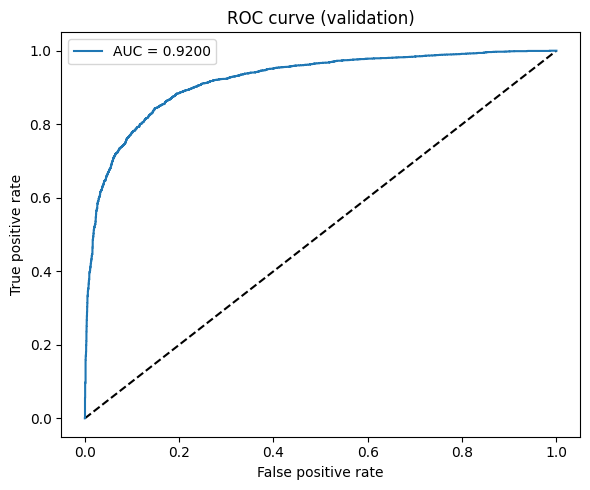

Validation AUC (auc): 0.9200126721763084
Validation AUC (roc_auc_score): 0.9200126721763084


In [6]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

y_pred_proba = model.predict(X_test, batch_size=128, verbose=0)[:, 1]
y_true = y_test.argmax(axis=1)

fpr_keras, tpr_keras, thresholds_keras = roc_curve(y_true, y_pred_proba)
auc_keras = auc(fpr_keras, tpr_keras)
auc_sklearn = roc_auc_score(y_true, y_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot([0, 1], [0, 1], "k--")
plt.plot(fpr_keras, tpr_keras, label="AUC = {:.4f}".format(auc_keras))
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve (validation)")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

print("Validation AUC (auc):", float(auc_keras))
print("Validation AUC (roc_auc_score):", float(auc_sklearn))



In [7]:
base_test_dir = TEST_DIR
test_files = glob(os.path.join(base_test_dir, "*.tif"))
test_files = sorted(test_files)

submission_parts = []
file_batch = 5000
max_idx = len(test_files)

for idx in range(0, max_idx, file_batch):
    print("Indexes: %i - %i" % (idx, min(idx + file_batch, max_idx)))
    batch_paths = test_files[idx : idx + file_batch]
    test_df = pd.DataFrame({"path": batch_paths})
    test_df["id"] = test_df["path"].map(
        lambda x: os.path.splitext(os.path.basename(x))[0]
    )
    test_df["image"] = test_df["path"].map(imread)

    K_test = np.stack(test_df["image"].values).astype("float32")
    K_test = (K_test - train_mean) / train_std

    preds = model.predict(K_test, batch_size=128, verbose=0)[:, 1]
    test_df["label"] = preds.astype("float32")

    submission_parts.append(test_df[["id", "label"]])

    del test_df, K_test, preds
    gc.collect()

submission = pd.concat(submission_parts, ignore_index=True)

if os.path.exists(SAMPLE_SUB_CSV):
    sample_sub = pd.read_csv(SAMPLE_SUB_CSV)
    submission = sample_sub[["id"]].merge(submission, on="id", how="left")
    submission["label"] = submission["label"].fillna(0.5).astype("float32")

submission.head()



Indexes: 0 - 5000
Indexes: 5000 - 10000
Indexes: 10000 - 15000
Indexes: 15000 - 20000
Indexes: 20000 - 25000
Indexes: 25000 - 30000
Indexes: 30000 - 35000
Indexes: 35000 - 40000
Indexes: 40000 - 45000
Indexes: 45000 - 45561


,id,label
0,acfe80838488fae3c89bd21ade75be5c34e66be7,0.092331
1,a1991e73a9b676faddd2bd47c39754b14d1eb923,0.079434
2,94fa32b29cc1c00403176c0795fffa3cfaa0f20e,0.947982
3,0b820b71670c039dd0a51333d1c919f471a9e940,0.762173
4,4b7a73f1fe1dafe2ffb7d2c0b83107f060b8d693,0.115492


In [8]:
submission.to_csv("submission.csv", index=False, header=True)
print("Wrote submission.csv with shape:", submission.shape)
print(submission.describe(include="all").head())

Wrote submission.csv with shape: (45561, 2)
                                              id         label
count                                      45561  45561.000000
unique                                     45561           NaN
top     acfe80838488fae3c89bd21ade75be5c34e66be7           NaN
freq                                           1           NaN
mean                                         NaN      0.451674


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
